# Задача 6. Кластеризация держателей кредитных карт
Цель: применить несколько алгоритмов кластеризации, сравнить результаты, определить оптимальное число кластеров для k‑средних и оценить долю объектов, которые трудно отнести к какому-либо кластеру.

In [1]:
# Настройки и импорты
import sys
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
 )
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def ensure_package(pkg: str) -> None:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', pkg])

ensure_package('kagglehub')
import kagglehub  # noqa: E402

## Загрузка данных (ccdata)

In [2]:
# Загрузка датасета ccdata (Credit Card Dataset for Clustering)
import contextlib
import io

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    data_root = Path(kagglehub.dataset_download('arjunbhasin2013/ccdata'))

csv_candidates = sorted(data_root.rglob('*.csv'))
if not csv_candidates:
    raise FileNotFoundError(f'Не найден CSV в {data_root}')

# В датасете обычно файл называется 'CC GENERAL.csv'
csv_path = None
for p in csv_candidates:
    if p.name.lower().replace(' ', '') in {'ccgeneral.csv', 'cc_general.csv'}:
        csv_path = p
        break
if csv_path is None:
    csv_path = csv_candidates[0]

data = pd.read_csv(csv_path)
print('Файл:', csv_path.name)
print('Размер:', data.shape)
display(data.head())

Using Colab cache for faster access to the 'ccdata' dataset.
Файл: CC GENERAL.csv
Размер: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Предобработка и PCA

Числовых признаков: 17
Пропуски есть?: True


,missing_fraction
MINIMUM_PAYMENTS,0.034972
CREDIT_LIMIT,0.000112


Компонент достаточно для 90% дисперсии: 10


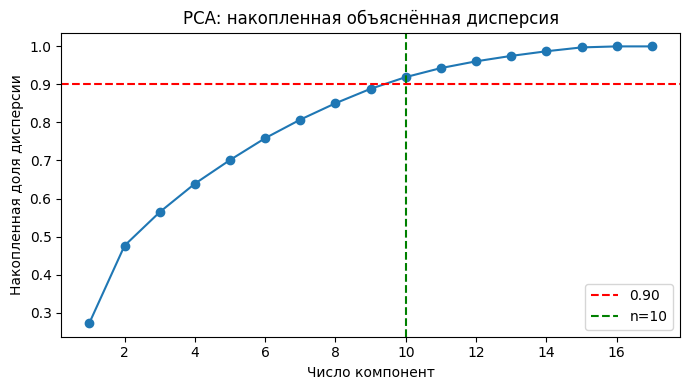

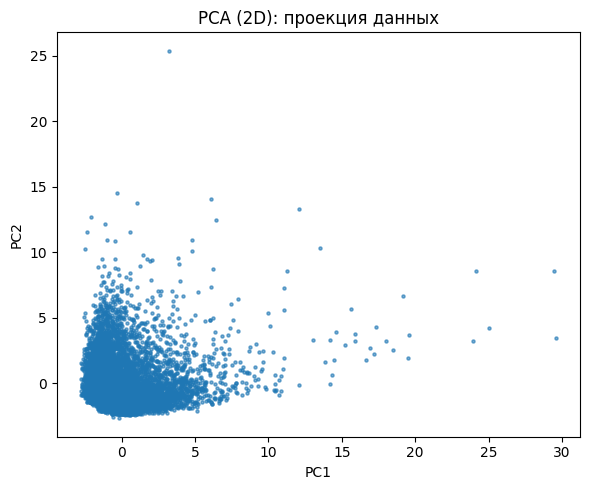

In [3]:
# Чистка признаков: убираем ID и нечисловые столбцы, импутация + стандартизация
id_cols = [c for c in data.columns if 'id' in c.lower()]
X_raw = data.drop(columns=id_cols, errors='ignore').copy()

cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
X_num = X_raw.drop(columns=cat_cols, errors='ignore')

# Базовые проверки
missing_frac = X_num.isna().mean().sort_values(ascending=False)
print('Числовых признаков:', X_num.shape[1])
print('Пропуски есть?:', bool((missing_frac > 0).any()))
if (missing_frac > 0).any():
    display(missing_frac[missing_frac > 0].head(10).to_frame('missing_fraction'))

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X_num)
X_scaled = scaler.fit_transform(X_imputed)

# PCA: будем кластеризовать в PCA-пространстве для устойчивости (шум/корреляции)
pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cum_var >= 0.90) + 1)
print('Компонент достаточно для 90% дисперсии:', n_90)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='0.90')
plt.axvline(n_90, color='green', linestyle='--', label=f'n={n_90}')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.title('PCA: накопленная объяснённая дисперсия')
plt.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Быстрая 2D-визуализация в PCA (первые 2 компоненты)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.6)
plt.title('PCA (2D): проекция данных')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

## Подбор оптимального k для KMeans

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,115531.511983,0.224174,1885.136748,1.815032
1,3,99804.707078,0.258645,1795.887779,1.498041
2,4,86971.506008,0.216915,1813.780299,1.479476
3,5,79581.806601,0.211810,1694.134612,1.451855
4,6,72944.670389,0.224069,1641.220843,1.407695
5,7,68261.304762,0.228878,1563.619086,1.395472
6,8,63001.841795,0.244389,1558.607859,1.293922
7,9,58470.632816,0.248580,1555.923503,1.219059
8,10,55312.189726,0.241021,1518.568038,1.280524
9,11,52577.884419,0.236223,1484.115277,1.245130


Оптимальное k (по максимуму silhouette): 3


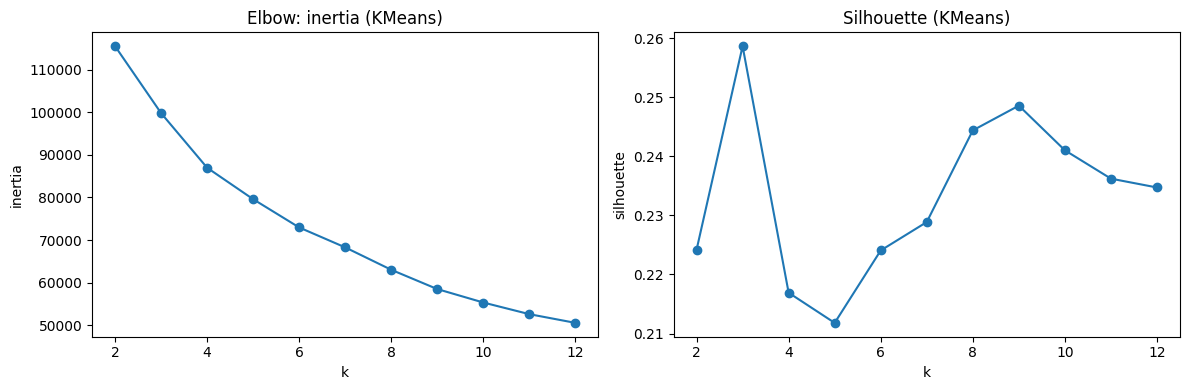

In [4]:
# Подбор k для KMeans: elbow (inertia) + silhouette
k_values = list(range(2, 13))
rows = []
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(float(km.inertia_))
    sil = float(silhouette_score(X_pca, labels))
    ch = float(calinski_harabasz_score(X_pca, labels))
    db = float(davies_bouldin_score(X_pca, labels))
    rows.append({'k': k, 'inertia': inertias[-1], 'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db})

k_df = pd.DataFrame(rows).sort_values('k')
display(k_df)

best_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])
print('Оптимальное k (по максимуму silhouette):', best_k)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_values, inertias, marker='o')
ax[0].set_title('Elbow: inertia (KMeans)')
ax[0].set_xlabel('k')
ax[0].set_ylabel('inertia')
ax[1].plot(k_values, k_df['silhouette'].values, marker='o')
ax[1].set_title('Silhouette (KMeans)')
ax[1].set_xlabel('k')
ax[1].set_ylabel('silhouette')
plt.tight_layout()
plt.show()

## Несколько алгоритмов кластеризации и сравнение
Ниже: KMeans/GMM/Agglomerative/DBSCAN, метрики качества и визуализация (t‑SNE).

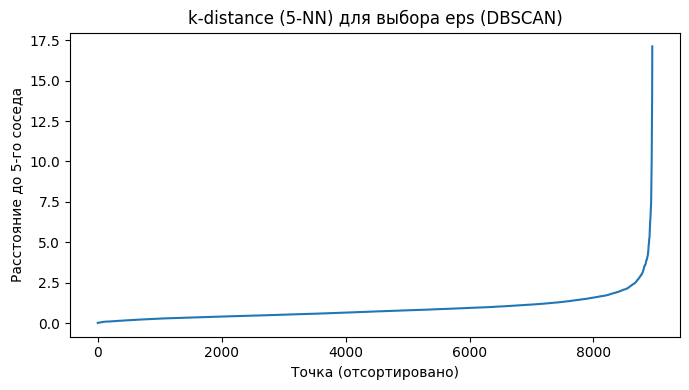

eps-кандидаты: [0.5, 0.8, 0.847, 0.987, 1.0, 1.081, 1.197, 1.2, 1.367, 1.5, 1.621, 2.0, 2.09, 2.5, 2.539]


,algorithm,noise_fraction,n_clusters,silhouette,calinski_harabasz,davies_bouldin
9,DBSCAN(eps=1.5),0.086369,4,0.233775,18.441823,0.656667
8,DBSCAN(eps=1.367),0.110503,2,0.123857,6.571170,1.049567
6,DBSCAN(eps=1.197),0.144358,9,-0.003425,17.455594,0.819527
7,DBSCAN(eps=1.2),0.142793,9,-0.003634,18.737992,0.826400
4,DBSCAN(eps=1.0),0.220447,15,-0.061183,17.708460,0.840235
3,DBSCAN(eps=0.987),0.227039,16,-0.112531,16.093080,0.847084
5,DBSCAN(eps=1.081),0.186480,7,-0.115976,17.056717,0.898953
1,DBSCAN(eps=0.8),0.357654,24,-0.291801,23.488483,0.989486
2,DBSCAN(eps=0.847),0.315642,25,-0.308209,13.090032,0.932435
0,DBSCAN(eps=0.5),0.623575,37,-0.398545,30.791606,0.971318


,algorithm,noise_fraction,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,KMeans(k=3),0.000000,3,0.258645,1795.887779,1.498041
2,Agglomerative(k=3),0.000000,3,0.251152,1463.985184,1.566344
12,DBSCAN(eps=1.5),0.086369,4,0.233775,18.441823,0.656667
11,DBSCAN(eps=1.367),0.110503,2,0.123857,6.571170,1.049567
1,GMM(k=3),0.000000,3,0.089641,952.200231,2.411178
9,DBSCAN(eps=1.197),0.144358,9,-0.003425,17.455594,0.819527
10,DBSCAN(eps=1.2),0.142793,9,-0.003634,18.737992,0.826400
7,DBSCAN(eps=1.0),0.220447,15,-0.061183,17.708460,0.840235
6,DBSCAN(eps=0.987),0.227039,16,-0.112531,16.093080,0.847084
8,DBSCAN(eps=1.081),0.186480,7,-0.115976,17.056717,0.898953


,pair,ARI,NMI,coverage
1,KMeans vs Agglomerative,0.527741,0.453170,1.000000
0,KMeans vs GMM,0.097243,0.176910,1.000000
3,GMM vs Agglomerative,0.056825,0.147585,1.000000
2,KMeans vs DBSCAN(eps=1.5),0.004300,0.006450,0.913631
5,Agglomerative vs DBSCAN(eps=1.5),0.002566,0.004384,0.913631
4,GMM vs DBSCAN(eps=1.5),0.000566,0.004125,0.913631


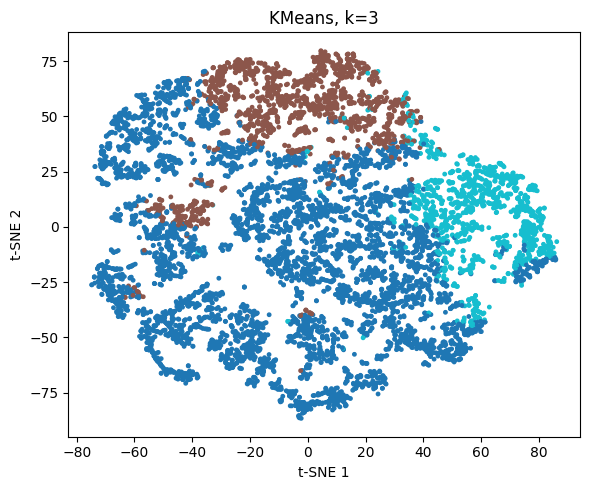

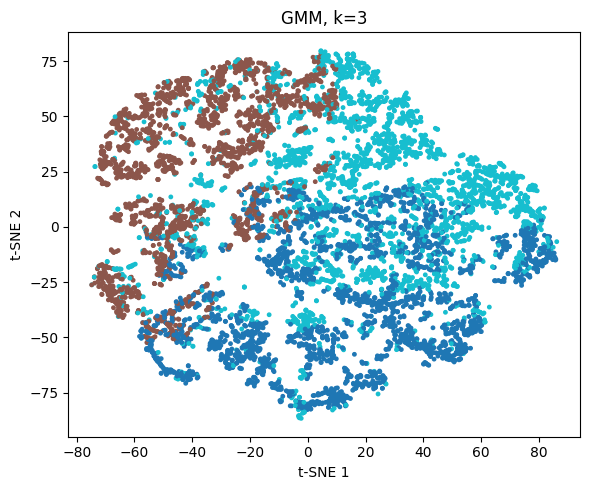

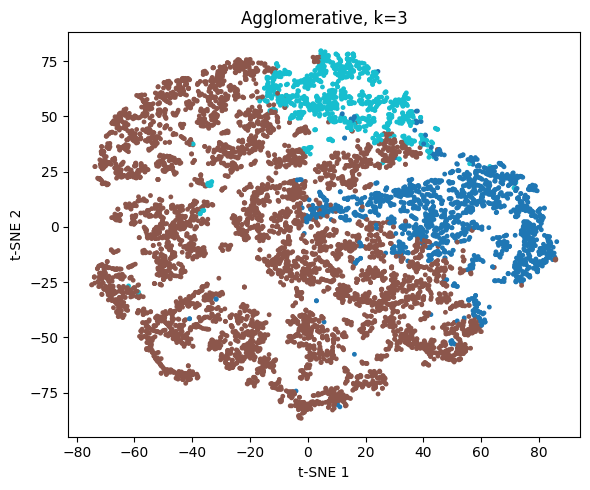

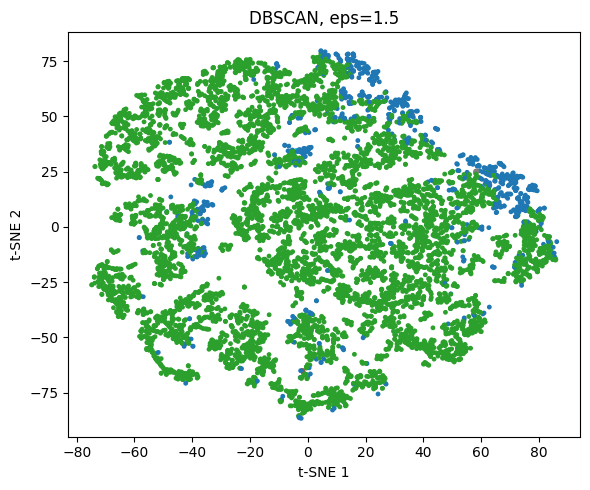

In [7]:
# Запуск нескольких алгоритмов кластеризации и сравнение качества
def clustering_metrics(X: np.ndarray, labels: np.ndarray) -> dict:
    labels = np.asarray(labels)
    # Для метрик исключаем шум DBSCAN (-1), если он есть
    mask = labels != -1
    uniq = np.unique(labels[mask])
    if len(uniq) < 2:
        return {'n_clusters': int(len(uniq)), 'silhouette': np.nan, 'calinski_harabasz': np.nan, 'davies_bouldin': np.nan}
    X_use = X[mask]
    y_use = labels[mask]
    return {
        'n_clusters': int(len(uniq)),
        'silhouette': float(silhouette_score(X_use, y_use)),
        'calinski_harabasz': float(calinski_harabasz_score(X_use, y_use)),
        'davies_bouldin': float(davies_bouldin_score(X_use, y_use)),
    }

# KMeans
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans.fit_predict(X_pca)

# GMM (Gaussian Mixture)
gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE, covariance_type='full')
labels_gmm = gmm.fit_predict(X_pca)
resp_gmm = gmm.predict_proba(X_pca)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_agg = agg.fit_predict(X_pca)

# DBSCAN: подберём eps по k-distance (k=5) и попробуем несколько значений
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)
dists, _ = nn.kneighbors(X_pca)
kdist = np.sort(dists[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(kdist)
plt.title('k-distance (5-NN) для выбора eps (DBSCAN)')
plt.xlabel('Точка (отсортировано)')
plt.ylabel('Расстояние до 5-го соседа')
plt.tight_layout()
plt.show()

# Кандидаты eps: квантили + несколько фиксированных значений
quantiles = [0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97]
eps_q = [float(np.quantile(kdist, q)) for q in quantiles]
eps_fixed = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
eps_candidates = sorted(set([round(e, 3) for e in (eps_q + eps_fixed)]))
print('eps-кандидаты:', eps_candidates)

dbscan_rows = []
best_db = None
best_db_score = -np.inf
for eps in eps_candidates:
    dbs = DBSCAN(eps=eps, min_samples=5)
    labels = dbs.fit_predict(X_pca)
    m = clustering_metrics(X_pca, labels)
    noise_frac = float(np.mean(labels == -1))
    n_clusters = m['n_clusters']
    dbscan_rows.append({
        'algorithm': f'DBSCAN(eps={eps})',
        'noise_fraction': noise_frac,
        **m,
    })
    if not np.isnan(m['silhouette']) and m['silhouette'] > best_db_score:
        best_db_score = m['silhouette']
        best_db = (eps, labels)

dbscan_df = pd.DataFrame(dbscan_rows)
display(dbscan_df.sort_values(['silhouette'], ascending=False, na_position='last').head(12))

rows = []
rows.append({'algorithm': f'KMeans(k={best_k})', 'noise_fraction': 0.0, **clustering_metrics(X_pca, labels_km)})
rows.append({'algorithm': f'GMM(k={best_k})', 'noise_fraction': 0.0, **clustering_metrics(X_pca, labels_gmm)})
rows.append({'algorithm': f'Agglomerative(k={best_k})', 'noise_fraction': 0.0, **clustering_metrics(X_pca, labels_agg)})
for r in dbscan_rows:
    # добавим только варианты, где есть >=2 кластера, чтобы таблица сравнения была осмысленной
    if r['n_clusters'] >= 2:
        rows.append(r)

compare_df = pd.DataFrame(rows)
display(compare_df.sort_values(['silhouette'], ascending=False, na_position='last'))

# Сравнение разбиений между алгоритмами (ARI/NMI): насколько похожи разбиения
def partition_similarity(la: np.ndarray, lb: np.ndarray) -> dict:
    la = np.asarray(la)
    lb = np.asarray(lb)
    if la.shape != lb.shape:
        raise ValueError('la и lb должны быть одинаковой длины')
    # Если один из алгоритмов помечает шум как -1 (DBSCAN), сравниваем только по точкам,
    # которые НЕ шум у обоих разбиений. Это делает сравнение корректнее «по смыслу».
    mask = (la != -1) & (lb != -1)
    coverage = float(np.mean(mask))
    if mask.sum() == 0:
        return {'ARI': np.nan, 'NMI': np.nan, 'coverage': coverage}
    return {
        'ARI': float(adjusted_rand_score(la[mask], lb[mask])),
        'NMI': float(normalized_mutual_info_score(la[mask], lb[mask])),
        'coverage': coverage,
    }

labels_by_alg = {
    'KMeans': labels_km,
    'GMM': labels_gmm,
    'Agglomerative': labels_agg,
}
if best_db is not None:
    labels_by_alg[f'DBSCAN(eps={best_db[0]})'] = best_db[1]

pairs = []
algs = list(labels_by_alg.keys())
for i in range(len(algs)):
    for j in range(i + 1, len(algs)):
        a, b = algs[i], algs[j]
        la, lb = labels_by_alg[a], labels_by_alg[b]
        sim = partition_similarity(la, lb)
        pairs.append({
            'pair': f'{a} vs {b}',
            **sim,
        })

sim_df = pd.DataFrame(pairs).sort_values(['ARI', 'NMI'], ascending=False, na_position='last')
display(sim_df)

# Визуализация на t-SNE для сравнения разбиений
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_pca)

def plot_labels(title: str, labels: np.ndarray):
    plt.figure(figsize=(6, 5))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, s=6, cmap='tab10')
    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.tight_layout()
    plt.show()

plot_labels(f'KMeans, k={best_k}', labels_km)
plot_labels(f'GMM, k={best_k}', labels_gmm)
plot_labels(f'Agglomerative, k={best_k}', labels_agg)
if best_db is not None:
    plot_labels(f'DBSCAN, eps={best_db[0]}', best_db[1])
else:
    print('DBSCAN не дал разбиения на >=2 кластера ни для одного eps-кандидата')

## Интерпретация кластеров и “трудные” объекты
Ниже: z‑профили кластеров (что общего внутри кластера) и оценка “трудных” объектов для KMeans/GMM/DBSCAN.

Короткая интерпретация `ARI/NMI` (см. таблицу `sim_df` выше): чем ближе метрики к 1, тем более похожи разбиения двух алгоритмов. Если в паре участвует DBSCAN, сравнение считается только по объектам, которые DBSCAN не пометил шумом (`coverage` показывает долю таких объектов).

KMeans: топ признаков (z-средние) по каждому кластеру

Кластер 0:


,z-mean
ONEOFF_PURCHASES_FREQUENCY,-0.235699
PURCHASES_TRX,-0.243469
PAYMENTS,-0.285356
CASH_ADVANCE_TRX,-0.299396
CASH_ADVANCE,-0.310581
CASH_ADVANCE_FREQUENCY,-0.334284
CREDIT_LIMIT,-0.338003
BALANCE,-0.367909



Кластер 1:


,z-mean
CASH_ADVANCE_FREQUENCY,1.554024
CASH_ADVANCE,1.376897
CASH_ADVANCE_TRX,1.337003
BALANCE,1.157513
CREDIT_LIMIT,0.597523
PAYMENTS,0.442354
PURCHASES_INSTALLMENTS_FREQUENCY,-0.558068
PURCHASES_FREQUENCY,-0.646710



Кластер 2:


,z-mean
PURCHASES_TRX,1.670713
ONEOFF_PURCHASES_FREQUENCY,1.554718
PURCHASES,1.526890
ONEOFF_PURCHASES,1.281238
INSTALLMENTS_PURCHASES,1.256032
PURCHASES_FREQUENCY,1.138322
PURCHASES_INSTALLMENTS_FREQUENCY,0.948834
CREDIT_LIMIT,0.891746


KMeans: доля неоднозначных (dist1/dist2 > 0.90): 9.35 %
KMeans: доля точек с silhouette < 0: 8.5 %


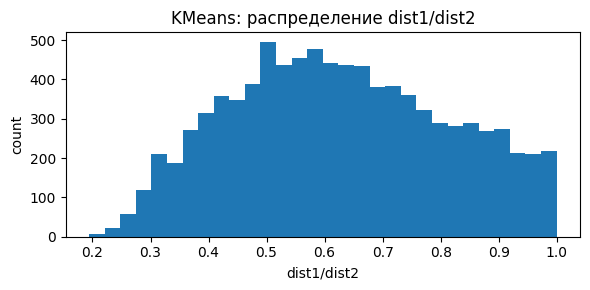

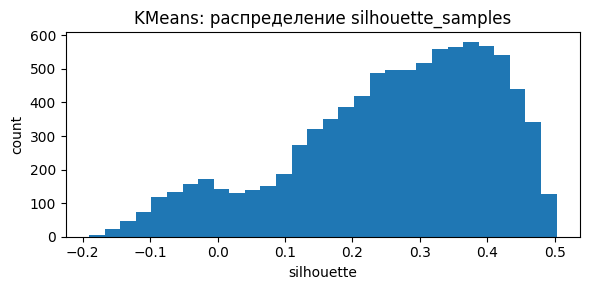

GMM: доля низкой уверенности (max responsibility < 0.60): 0.68 %


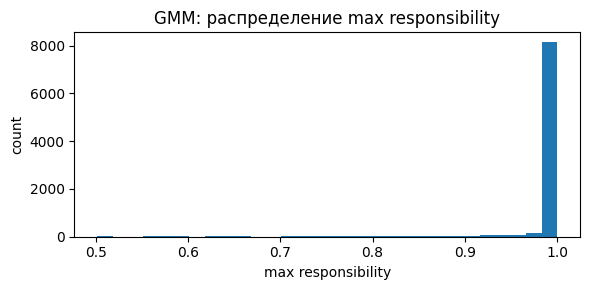

DBSCAN: доля шума (-1) при eps= 1.5 : 8.64 %

Выводы:
- Оптимальное k для KMeans выбрано по максимуму silhouette: k=3.
- Сравнение алгоритмов: см. таблицу метрик качества и таблицу ARI/NMI (похожесть разбиений).
- Общие “типы” клиентов видно по z-профилям (например, активные покупки vs cash advance).
- “Трудные” объекты: KMeans неоднозначные≈9.35% и silhouette<0≈8.5%; GMM низкая уверенность≈0.68%; DBSCAN: шум (-1)≈8.64%.


In [8]:
# Интерпретация: что общего внутри кластеров (на примере KMeans)
X_num_df = pd.DataFrame(X_imputed, columns=X_num.columns)

def cluster_z_profiles(labels: np.ndarray, top_n: int = 8) -> dict:
    labels = np.asarray(labels)
    mask = labels != -1
    df = X_num_df.loc[mask].copy()
    df['cluster'] = labels[mask]
    means = df.groupby('cluster').mean()
    overall_mean = X_num_df.mean()
    overall_std = X_num_df.std(ddof=0).replace(0, np.nan)
    z = (means - overall_mean) / overall_std
    out = {}
    for cl in z.index:
        top = z.loc[cl].abs().sort_values(ascending=False).head(top_n).index
        out[int(cl)] = z.loc[cl, top].sort_values(ascending=False).to_frame('z-mean')
    return out, z

profiles_km, z_km = cluster_z_profiles(labels_km, top_n=8)
print('KMeans: топ признаков (z-средние) по каждому кластеру')
for cl, dfz in profiles_km.items():
    print(f'\nКластер {cl}:')
    display(dfz)

# “Трудно отнести к кластеру”: неуверенные точки
dists_to_centers = kmeans.transform(X_pca)
sorted_d = np.sort(dists_to_centers, axis=1)
dist1 = sorted_d[:, 0]
dist2 = sorted_d[:, 1]
ratio = dist1 / (dist2 + 1e-12)
ambiguous_km = ratio > 0.90
ambiguous_km_pct = round(float(np.mean(ambiguous_km)) * 100, 2)
print('KMeans: доля неоднозначных (dist1/dist2 > 0.90):', ambiguous_km_pct, '%')

# KMeans: доля точек с отрицательным silhouette (часто трактуют как "плохо вписанные")
sil_km = silhouette_samples(X_pca, labels_km)
neg_sil = sil_km < 0
neg_sil_pct = round(float(np.mean(neg_sil)) * 100, 2)
print('KMeans: доля точек с silhouette < 0:', neg_sil_pct, '%')

plt.figure(figsize=(6, 3))
plt.hist(ratio, bins=30)
plt.title('KMeans: распределение dist1/dist2')
plt.xlabel('dist1/dist2')
plt.ylabel('count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(sil_km, bins=30)
plt.title('KMeans: распределение silhouette_samples')
plt.xlabel('silhouette')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# GMM: уверенность по максимальной ответственности
max_resp = resp_gmm.max(axis=1)
low_conf = max_resp < 0.60
low_conf_pct = round(float(np.mean(low_conf)) * 100, 2)
print('GMM: доля низкой уверенности (max responsibility < 0.60):', low_conf_pct, '%')

plt.figure(figsize=(6, 3))
plt.hist(max_resp, bins=30)
plt.title('GMM: распределение max responsibility')
plt.xlabel('max responsibility')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# DBSCAN: шум (-1) как “не отнеслось к кластеру”
noise_pct = None
if best_db is not None:
    eps_best, labels_db = best_db
    noise_frac = float(np.mean(labels_db == -1))
    noise_pct = round(noise_frac * 100, 2)
    print('DBSCAN: доля шума (-1) при eps=', eps_best, ':', noise_pct, '%')
else:
    print('DBSCAN: нет валидного разбиения (>=2 кластера) для выбранных eps')

# Короткие выводы (текст)
print('\nВыводы:')
print(f'- Оптимальное k для KMeans выбрано по максимуму silhouette: k={best_k}.')
print('- Сравнение алгоритмов: см. таблицу метрик качества и таблицу ARI/NMI (похожесть разбиений).')
print('- Общие “типы” клиентов видно по z-профилям (например, активные покупки vs cash advance).')
dbscan_part = 'нет валидного разбиения' if noise_pct is None else f'шум (-1)≈{noise_pct}%'
print(f'- “Трудные” объекты: KMeans неоднозначные≈{ambiguous_km_pct}% и silhouette<0≈{neg_sil_pct}%; GMM низкая уверенность≈{low_conf_pct}%; DBSCAN: {dbscan_part}.')